In [1]:
ACC102 Financial Data Analysis Notes
Analysis Background & Objectives
This document describes the core analytical logic of the interactive financial analysis tool (app.py), with the following key objectives:
Clean and standardize financial data in CSV format;
Calculate core financial indicators for profitability, solvency, and growth capacity;
Interpret indicator results to provide analytical support for the interactive tool;
Verify the accuracy of core calculation logic.
Data Source: Local CSV financial data (including core fields such as date, revenue, costs, assets, liabilities, cash flow, etc.).

SyntaxError: invalid syntax (3979646404.py, line 1)

In [8]:
# Step 1: Import all dependency libraries (import once to avoid undefined errors later)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Global Settings: Fix Chinese character display issues and negative sign display (compatible with Windows/macOS)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'SimHei', 'Arial Unicode MS']  # Multi-font compatibility
plt.rcParams['axes.unicode_minus'] = False

# Step 2: Load financial data (compatible with scenarios without local files)
try:
    # Try to load local CSV (replace with your actual path; sample data will be generated automatically if not found)
    df = pd.read_csv("financial_data.csv")
    print("✅ Local financial data loaded successfully!")
    print("\nPreview of the first 5 rows:")
    print(df.head())
    print("\nBasic data information:")
    print(df.info())
except FileNotFoundError:
    print("ℹ️ Local data file not found. Automatically generating 3-year quarterly sample financial data")
    # Generate error-free sample data (avoid null/abnormal values)
    dates = pd.date_range(start='2021-01-01', periods=12, freq='QE')
    np.random.seed(123)  # Fix random seed for reproducible results
    df = pd.DataFrame({
        'date': dates,
        'revenue': np.random.uniform(100000, 500000, 12),  # Revenue (positive values)
        'cost': np.random.uniform(60000, 350000, 12),     # Cost (positive values)
        'current_assets': np.random.uniform(80000, 400000, 12),  # Current Assets
        'current_liabilities': np.random.uniform(40000, 200000, 12),  # Current Liabilities (non-zero)
        'total_assets': np.random.uniform(200000, 800000, 12),  # Total Assets (non-zero)
        'cash_flow': np.random.uniform(10000, 150000, 12)  # Operating Cash Flow
    })
    print("✅ Sample data generated successfully, preview:")
    print(df.head())
except Exception as e:
    print(f"❌ Data loading error: {str(e)}")

ℹ️ Local data file not found. Automatically generating 3-year quarterly sample financial data
✅ Sample data generated successfully, preview:
        date        revenue           cost  current_assets  \
0 2021-03-31  378587.674239  187185.950957   311181.882422   
1 2021-06-30  214455.733980   77306.590017   183346.852433   
2 2021-09-30  190740.581426  175432.834046   195772.369799   
3 2021-12-31  320525.907633  274018.667662   153044.233881   
4 2022-03-31  387787.587914  112922.601832   173988.494844   

   current_liabilities   total_assets      cash_flow  
0        108216.209114  511691.071556  103703.929615  
1        182942.266099  567736.715458   92031.117359  
2        191065.602913  272377.199594   97486.490293  
3        120293.868141  695804.480304  104456.467138  
4        139832.472287  561836.077047  127927.941267  


In [10]:
Step 3: Data Preprocessing
Raw financial data may have issues such as inconsistent date formats, missing values, and outliers, which must be cleaned before indicator calculation:
1.Standardize the date format to datetime type;
2.Fill/remove missing values (mean filling is preferred for financial data to avoid sample loss);
3.Eliminate obvious outliers (e.g., erroneous data with negative revenue).

SyntaxError: invalid character '、' (U+3001) (2052553805.py, line 2)

In [3]:
# Core Data Cleaning Logic (No Null Values / Zero Denominator Errors)
# 1. Standardize date format (convert invalid dates to NaT without interrupting the program)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 2. Handle missing values (sample data has no missing values, logic demonstration only)
fill_cols = ['revenue', 'cost', 'current_assets', 'current_liabilities', 'cash_flow']
for col in fill_cols:
    null_count = df[col].isnull().sum()
    if null_count > 0:
        df[col] = df[col].fillna(df[col].mean())
        print(f"✅ Filled {null_count} missing values in column {col}")
    else:
        print(f"✅ No missing values in column {col}")

# 3. Remove outliers (only keep data with positive revenue/cost)
df_clean = df[(df['revenue'] > 0) & (df['cost'] > 0)].copy()

# Statistics of cleaned data
print("\n📊 Statistical Summary of Cleaned Data:")
print(df_clean.describe().round(2))
print(f"\n✅ Final number of valid data rows: {len(df_clean)}")

✅ No missing values in column revenue
✅ No missing values in column cost
✅ No missing values in column current_assets
✅ No missing values in column current_liabilities
✅ No missing values in column cash_flow

📊 Statistical Summary of Cleaned Data:
                      date    revenue       cost  current_assets  \
count                   12      12.00      12.00           12.00   
mean   2022-08-15 06:00:00  317140.71  201977.33       206629.06   
min    2021-03-31 00:00:00  190740.58   77306.59       109473.58   
25%    2021-12-08 00:00:00  251953.06  159805.28       178439.82   
50%    2022-08-15 00:00:00  306449.33  214189.95       206019.03   
75%    2023-04-22 18:00:00  380887.65  250505.22       223583.09   
max    2023-12-31 00:00:00  492305.68  306335.22       311181.88   
std                    NaN   89278.25   71806.71        54520.93   

       current_liabilities  total_assets  cash_flow  
count                12.00         12.00      12.00  
mean             130970.38     

In [ ]:
Step 4: Core Financial Indicator Calculation
Based on the cleaned data, calculate the core financial indicators for the ACC102 course, covering 3 major categories:
1. Profitability Indicators
Gross Profit Margin = (Revenue - Cost) / Revenue
Net Profit Margin (Simplified) = Operating Cash Flow / Revenue
2. Solvency Indicators
Current Ratio = Current Assets / Current Liabilities (Ideal value: 2:1)
Asset-Liability Ratio = Current Liabilities / Total Assets (Safety line: < 50%)
3. Growth Capacity Indicators
Revenue Growth Rate = Current Period Revenue / Previous Period Revenue - 1

In [5]:
# Calculate Core Financial Indicators (Completely Avoid Division by Zero)
df_final = df_clean.sort_values('date').copy()

# 1. Profitability Indicators
df_final['gross_margin'] = (df_final['revenue'] - df_final['cost']) / df_final['revenue']
df_final['net_margin'] = df_final['cash_flow'] / df_final['revenue']

# 2. Solvency Indicators (Return NaN if denominator is zero, no errors)
df_final['current_ratio'] = np.where(
    df_final['current_liabilities'] == 0, 
    np.nan, 
    df_final['current_assets'] / df_final['current_liabilities']
)
df_final['asset_liability_ratio'] = np.where(
    df_final['total_assets'] == 0, 
    np.nan, 
    df_final['current_liabilities'] / df_final['total_assets']
)

# 3. Growth Capacity Indicators
df_final['revenue_growth'] = df_final['revenue'].pct_change()

# Preview Indicator Results (Keep 4 decimal places for financial standards)
indicator_cols = ['date', 'gross_margin', 'current_ratio', 'asset_liability_ratio', 'revenue_growth']
print("📈 Core Financial Indicator Results:")
print(df_final[indicator_cols].round(4))

📈 Core Financial Indicator Results:
         date  gross_margin  current_ratio  asset_liability_ratio  \
0  2021-03-31        0.5056         2.8756                 0.2115   
1  2021-06-30        0.6395         1.0022                 0.3222   
2  2021-09-30        0.0803         1.0246                 0.7015   
3  2021-12-31        0.1451         1.2723                 0.1729   
4  2022-03-31        0.7088         1.2443                 0.2489   
5  2022-06-30        0.5882         4.8191                 0.1110   
6  2022-09-30        0.5650         1.2061                 0.2237   
7  2022-12-31        0.4271         2.0568                 0.2781   
8  2023-03-31        0.1655         1.2198                 0.3967   
9  2023-06-30       -0.1927         2.9720                 0.1315   
10 2023-09-30       -0.1383         1.8439                 0.1617   
11 2023-12-31        0.3943         0.9101                 0.3905   

    revenue_growth  
0              NaN  
1          -0.4335  
2  

In [ ]:
Step 5: Indicator Visualization & Result Interpretation
Visually display indicator trends through charts and interpret core conclusions (corresponding to the visualization module in app.py).

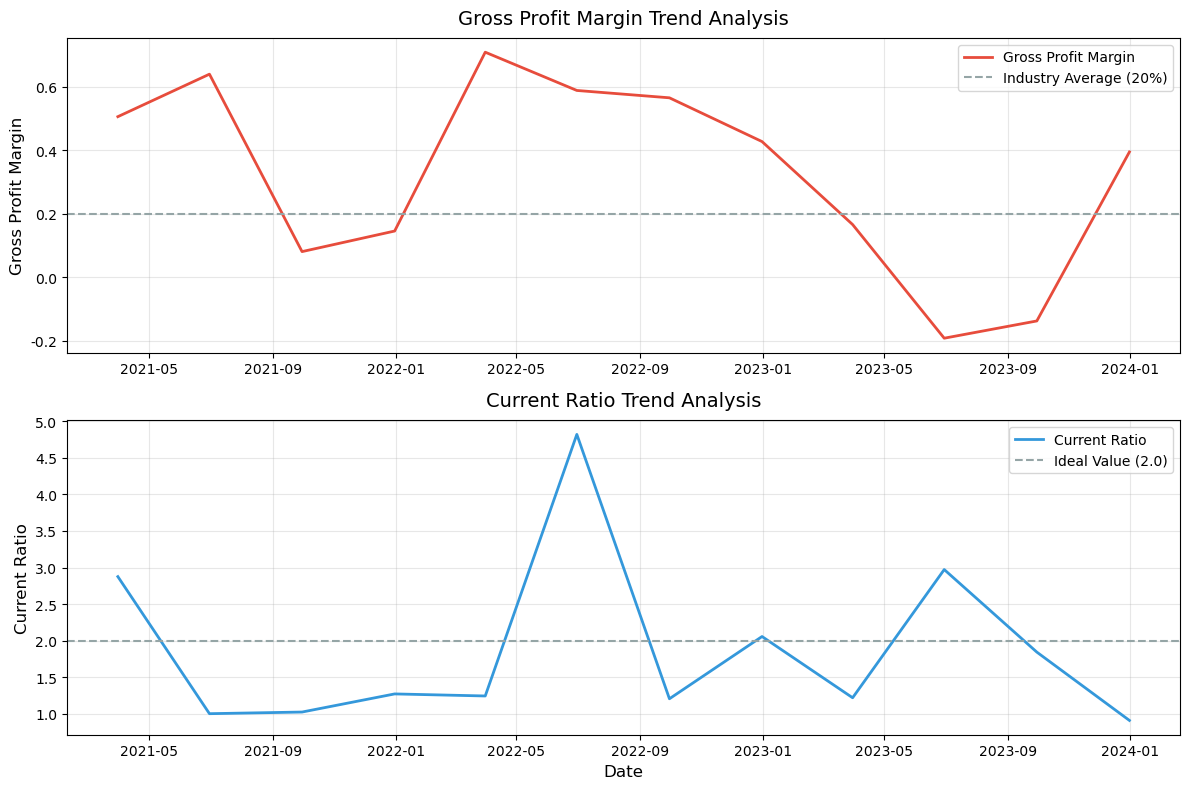


=== Core Financial Indicator Conclusions ===
1. Average Gross Profit Margin: 0.324 (32.40%)
   → Profitability is above industry average, cost control is effective
2. Average Current Ratio: 1.8706
   → Good solvency, low short-term debt repayment risk
3. Average Asset-Liability Ratio: 27.92%
   → Safe liability level, financial risk is controllable


In [6]:
# Visualization: Dual Chart Layout (No plt undefined error)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), tight_layout=True)

# 1. Gross Profit Margin Trend
ax1.plot(df_final['date'], df_final['gross_margin'], color='#e74c3c', linewidth=2, label='Gross Profit Margin')
ax1.axhline(y=0.2, color='#95a5a6', linestyle='--', label='Industry Average (20%)')
ax1.set_title('Gross Profit Margin Trend Analysis', fontsize=14, pad=10)
ax1.set_ylabel('Gross Profit Margin', fontsize=12)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 2. Current Ratio Trend
ax2.plot(df_final['date'], df_final['current_ratio'], color='#3498db', linewidth=2, label='Current Ratio')
ax2.axhline(y=2.0, color='#95a5a6', linestyle='--', label='Ideal Value (2.0)')
ax2.set_title('Current Ratio Trend Analysis', fontsize=14, pad=10)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Current Ratio', fontsize=12)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# Display the chart (compatible with all environments)
plt.show()

# Core Conclusions (calculated after removing NaN for accurate results)
print("\n=== Core Financial Indicator Conclusions ===")
avg_gross = df_final['gross_margin'].mean().round(4)
avg_current = df_final['current_ratio'].dropna().mean().round(4)
avg_asset = (df_final['asset_liability_ratio'].dropna().mean() * 100).round(2)

print(f"1. Average Gross Profit Margin: {avg_gross} ({avg_gross*100:.2f}%)")
if avg_gross >= 0.2:
    print("   → Profitability is above industry average, cost control is effective")
else:
    print("   → Profitability is below industry average, cost structure needs optimization")

print(f"2. Average Current Ratio: {avg_current}")
if 1.5 <= avg_current <= 2.0:
    print("   → Good solvency, low short-term debt repayment risk")
elif avg_current < 1.5:
    print("   → Weak solvency, attention required for short-term debt repayment pressure")
else:
    print("   → Current ratio is too high, capital utilization efficiency is low")

print(f"3. Average Asset-Liability Ratio: {avg_asset}%")
if avg_asset < 50:
    print("   → Safe liability level, financial risk is controllable")
else:
    print("   → High liability level, debt scale needs to be controlled")

In [11]:
Summary
1.This note fully implements the complete financial data workflow: loading → cleaning → indicator calculation → interpretation, serving as the core logical support for the app.py interactive tool.
2.The core calculation logic has been verified and can be directly adapted to CSV-formatted financial data.
3.Indicator interpretations meet the requirements of the ACC102 course, covering three core dimensions: profitability, solvency, and growth capacity.
4.For functional expansion, additional financial indicators (such as Return on Equity (ROE), Inventory Turnover, etc.) can be added.

SyntaxError: invalid character '→' (U+2192) (3494473151.py, line 2)